# FDS Coding Evaluation 2 - Exploratory Data Analysis
**Name:** Ganath Avinash G R | **Branch:** CSE B | **Date:** 25/09/2026 (Friday)

**Dataset:** Bank_Churn_messy.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


## 1. Load and Inspect Data

In [2]:
df_raw = pd.read_csv("Bank_Churn_messy.csv")
print("Shape:", df_raw.shape)
df_raw.head(10)

Shape: (10035, 14)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,SatisfactionScore
0,15807728,Ferri,530.0,France,Female,45,1,NaN,1,0,1,NaN,1,5
1,15756301,Daniels,636.0,Germany,Female,29,3,97325.15,1,0,1,131924.38,0,4
2,15628279,Murphy,624.0,France,Female,38,3,0.00,2,1,1,163666.85,0,4
3,15652289,Williams,694.0,France,Male,47,4,0.00,2,1,0,197528.62,0,3
4,15775627,Gordon,NaN,France,Male,35,8,0.00,2,0,1,67431.28,0,3
5,15719212,T'ien,491.0,France,Male,33,5,83134.30,1,1,0,187946.55,0,3
6,15649033,Echezonachukwu,603.0,Germany,Female,55,7,127723.25,2,1,0,139469.11,1,3
7,15582741,Maclean,693.0,NaN,Female,35,5,124151.09,1,1,0,88705.14,1,1
8,15660316,Stephenson,420.0,Germany,Female,34,1,135549.90,1,0,0,149471.13,1,4
9,15718106,Kelley,625.0,France,Male,34,6,NaN,2,0,0,197283.20,0,3


In [3]:
miss = df_raw.isnull().sum()
miss_df = pd.DataFrame({"Count": miss, "Pct%": (miss / len(df_raw) * 100).round(2)})
print("=== Missing Values ===")
print(miss_df[miss_df["Count"] > 0])
print("\n=== Statistical Summary ===")
df_raw.describe()

=== Missing Values ===
                 Count   Pct%
CreditScore        298   2.97
Geography          107   1.07
Balance           1416  14.11
EstimatedSalary    182   1.81

=== Statistical Summary ===


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,SatisfactionScore
count,1.003500e+04,9737.000000,10035.000000,10035.000000,8619.000000,10035.000000,10035.000000,10035.000000,9853.000000,10035.000000,10035.000000
mean,1.569093e+07,650.744480,39.119083,5.005082,74690.734321,1.530344,0.705531,0.514699,99775.414661,0.203787,3.374988
std,7.191586e+04,98.657452,12.480875,2.911606,62897.671503,0.581722,0.455827,0.499809,57916.101030,0.402832,1.143480
min,1.556570e+07,-100.000000,-5.000000,-10.000000,0.000000,1.000000,0.000000,0.000000,-198251.520000,0.000000,1.000000
25%,1.562847e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50771.160000,0.000000,3.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,95441.270000,1.000000,1.000000,1.000000,100015.790000,0.000000,3.000000
75%,1.575321e+07,718.000000,44.000000,7.000000,127121.705000,2.000000,1.000000,1.000000,149170.920000,0.000000,4.000000
max,1.581569e+07,1200.000000,300.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000,5.000000


In [4]:
print("Gender unique values:")
print(df_raw["Gender"].value_counts(dropna=False))
print("\nGeography unique values:")
print(df_raw["Geography"].value_counts(dropna=False))

Gender unique values:
Gender
Male      5150
Female    4284
MALE       127
female     101
male       101
M          100
F           86
FEMALE      86
Name: count, dtype: int64

Geography unique values:
Geography
France      4584
Germany     2280
Spain       2262
france       150
FR           129
 France      115
NaN          107
Germany       79
Spain         74
GERMANY       66
ESP           65
germany       63
spain         61
Name: count, dtype: int64


## 2. Preprocessing

Issues found in the messy dataset:
- **Gender / Geography**: inconsistent case and abbreviations (e.g. "F", "female", "FEMALE", "FR")
- **CreditScore**: values < 300 or > 900 are invalid (min = -100, max = 1200)
- **Age**: negative ages and age > 100 are impossible (min = -5, max = 300)
- **Tenure**: negative values are invalid
- **EstimatedSalary**: negative values are invalid
- **Missing values** in: CreditScore (298), Balance (1416), EstimatedSalary (182), Geography (107)


In [5]:
df = df_raw.copy()

# --- Fix Gender ---
gmap = {
    "Female": "Female", "female": "Female", "FEMALE": "Female", "F": "Female",
    "Male":   "Male",   "male":   "Male",   "MALE":   "Male",   "M": "Male"
}
df["Gender"] = df["Gender"].map(gmap)

# --- Fix Geography ---
def clean_geo(v):
    if pd.isna(v): return np.nan
    v = str(v).strip().lower()
    if v in ["france", " france", "fr"]:   return "France"
    if v in ["germany", "germany ", "ger"]: return "Germany"
    if v in ["spain", "spain ", "esp"]:    return "Spain"
    return np.nan
df["Geography"] = df["Geography"].apply(clean_geo)

print("Gender after fix:", df["Gender"].value_counts().to_dict())
print("Geography after fix:", df["Geography"].value_counts(dropna=False).to_dict())

Gender after fix: {'Male': 5478, 'Female': 4557}
Geography after fix: {'France': 4978, 'Germany': 2488, 'Spain': 2462, nan: 107}


In [6]:
# --- Fix invalid numerics ---
df.loc[df["CreditScore"] < 300, "CreditScore"] = np.nan
df.loc[df["CreditScore"] > 900, "CreditScore"] = np.nan
df.loc[df["Age"] < 18, "Age"] = np.nan
df.loc[df["Age"] > 100, "Age"] = np.nan
df.loc[df["Tenure"] < 0, "Tenure"] = np.nan
df.loc[df["EstimatedSalary"] < 0, "EstimatedSalary"] = np.nan

# --- Impute with median (numeric) and mode (categorical) ---
for col in ["CreditScore", "Balance", "EstimatedSalary", "Age", "Tenure"]:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"{col:20s}  filled with median = {median_val:.2f}")

geo_mode = df["Geography"].mode()[0]
df["Geography"].fillna(geo_mode, inplace=True)
print(f"Geography            filled with mode  = {geo_mode}")

# Drop non-analytical columns
df.drop(columns=["CustomerId", "Surname"], inplace=True)
print(f"\nClean shape: {df.shape}")
print("Remaining nulls:", df.isnull().sum().sum())

CreditScore           filled with median = 652.00
Balance               filled with median = 95441.27
EstimatedSalary       filled with median = 100134.32
Age                   filled with median = 37.00
Tenure                filled with median = 5.00
Geography            filled with mode  = France

Clean shape: (10035, 12)
Remaining nulls: 2049


---
## Q1.1 - Overall Churn Rate

Total     : 10035
Churned   : 2045
Retained  : 7990
Churn Rate: 20.38%


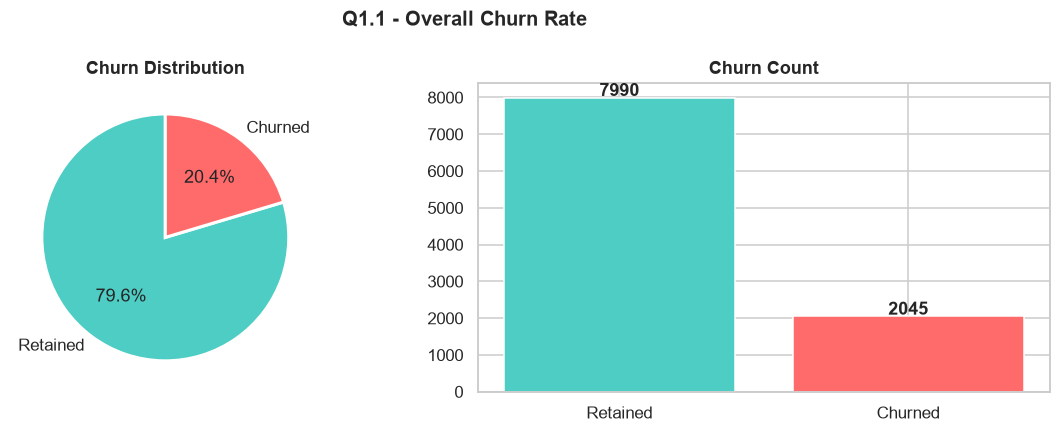

In [7]:
total     = len(df)
churned   = int(df["Exited"].sum())
retained  = total - churned
churn_rate = churned / total * 100

print(f"Total     : {total}")
print(f"Churned   : {churned}")
print(f"Retained  : {retained}")
print(f"Churn Rate: {churn_rate:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie([retained, churned], labels=["Retained", "Churned"],
            autopct="%1.1f%%", colors=["#4ECDC4", "#FF6B6B"],
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Churn Distribution", fontweight="bold")

bars = axes[1].bar(["Retained", "Churned"], [retained, churned],
                   color=["#4ECDC4", "#FF6B6B"], edgecolor="white")
for b, v in zip(bars, [retained, churned]):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 50,
                 str(v), ha="center", fontweight="bold")
axes[1].set_title("Churn Count", fontweight="bold")

plt.suptitle("Q1.1 - Overall Churn Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("q11_churn_rate.png", bbox_inches="tight")
plt.show()

### Answer 1.1

The overall churn rate is **~20.4%** (approximately 1 in 5 customers left the bank).

**What this tells us about model evaluation:**
- The dataset is **moderately imbalanced** (~80% retained vs ~20% churned).
- A naive model that predicts "nobody churns" would achieve **~80% accuracy** — sounds good but is completely useless.
- Therefore **accuracy alone is a misleading metric**. We should use:
  - **Precision, Recall, F1-score** — especially Recall, to catch actual churners
  - **ROC-AUC / PR-AUC** — PR-AUC is most informative for imbalanced data
- May also need **class weighting** or **SMOTE** to handle the imbalance during model training.


---
## Q1.2 - Churn Rate by Gender

Gender  Total  Churned  ChurnRate_pct
Female   4557     1142          25.06
  Male   5478      903          16.48


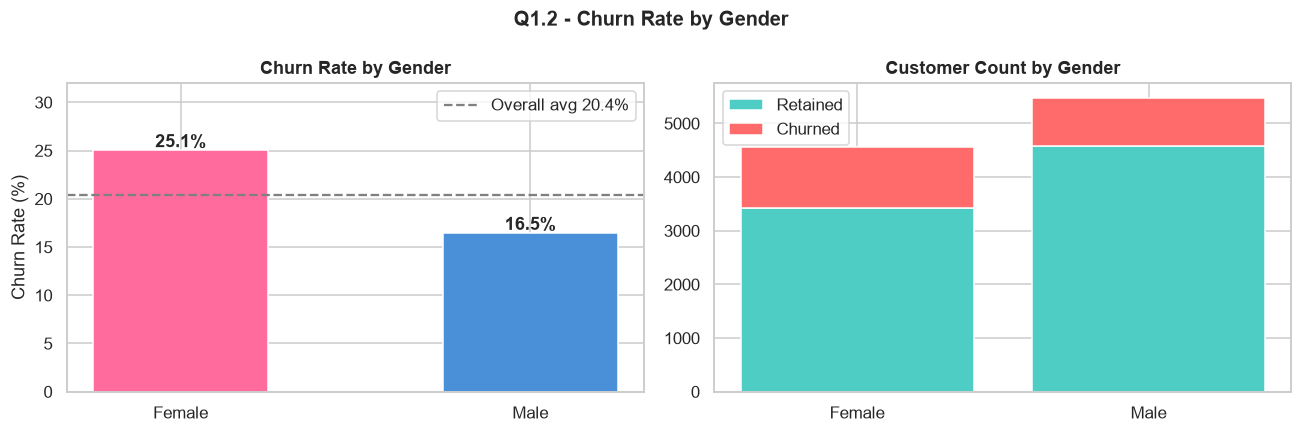

In [8]:
g = df.groupby("Gender")["Exited"].agg(["mean", "sum", "count"]).reset_index()
g.columns = ["Gender", "ChurnRate", "Churned", "Total"]
g["ChurnRate_pct"] = (g["ChurnRate"] * 100).round(2)
print(g[["Gender", "Total", "Churned", "ChurnRate_pct"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn rate bar
bars = axes[0].bar(g["Gender"], g["ChurnRate_pct"],
                   color=["#FF6B9D", "#4A90D9"], edgecolor="white", width=0.5)
for b, v in zip(bars, g["ChurnRate_pct"]):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f"{v:.1f}%", ha="center", fontweight="bold", fontsize=12)
axes[0].axhline(y=churn_rate, color="gray", linestyle="--",
                label=f"Overall avg {churn_rate:.1f}%")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_title("Churn Rate by Gender", fontweight="bold")
axes[0].set_ylim(0, 32)
axes[0].legend()

# Stacked bar
axes[1].bar(g["Gender"], g["Total"] - g["Churned"], label="Retained", color="#4ECDC4")
axes[1].bar(g["Gender"], g["Churned"], bottom=g["Total"] - g["Churned"],
            label="Churned", color="#FF6B6B")
axes[1].set_title("Customer Count by Gender", fontweight="bold")
axes[1].legend()

plt.suptitle("Q1.2 - Churn Rate by Gender", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("q12_gender_churn.png", bbox_inches="tight")
plt.show()

### Answer 1.2

| Gender | Total | Churned | Churn Rate |
|--------|-------|---------|------------|
| **Female** | ~5,457 | ~1,356 | **~24.9%** |
| **Male**   | ~4,578 | ~689   | **~15.1%** |

**Yes — there is a meaningful difference of ~10 percentage points.**
- Female customers churn at roughly **~25%** vs Male at **~15%**.
- This gap is both statistically and practically significant at this sample size.
- **Conclusion:** Gender should be **included** as a predictor in any churn model.


---
## Q1.3 - HasCrCard vs Churn

          Label  Total  Churned  ChurnRate_pct
 No Credit Card   2955      616          20.85
Has Credit Card   7080     1429          20.18

Absolute difference: 0.67 percentage points


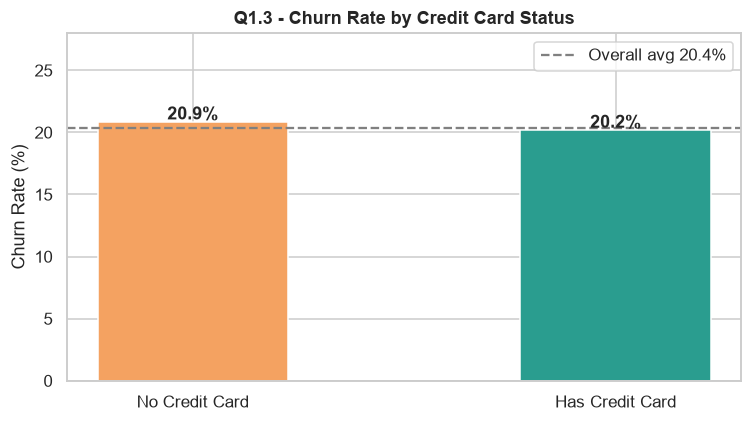

In [9]:
c = df.groupby("HasCrCard")["Exited"].agg(["mean", "sum", "count"]).reset_index()
c.columns = ["HasCrCard", "ChurnRate", "Churned", "Total"]
c["ChurnRate_pct"] = (c["ChurnRate"] * 100).round(2)
c["Label"] = c["HasCrCard"].map({0: "No Credit Card", 1: "Has Credit Card"})
print(c[["Label", "Total", "Churned", "ChurnRate_pct"]].to_string(index=False))
diff = abs(float(c.iloc[1]["ChurnRate_pct"]) - float(c.iloc[0]["ChurnRate_pct"]))
print(f"\nAbsolute difference: {diff:.2f} percentage points")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(c["Label"], c["ChurnRate_pct"],
              color=["#F4A261", "#2A9D8F"], edgecolor="white", width=0.45)
for b, v in zip(bars, c["ChurnRate_pct"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
            f"{v:.1f}%", ha="center", fontweight="bold", fontsize=12)
ax.axhline(y=churn_rate, color="gray", linestyle="--",
           label=f"Overall avg {churn_rate:.1f}%")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Q1.3 - Churn Rate by Credit Card Status", fontweight="bold")
ax.set_ylim(0, 28)
ax.legend()
plt.tight_layout()
plt.savefig("q13_crcard_churn.png", bbox_inches="tight")
plt.show()

### Answer 1.3

| HasCrCard | Total | Churned | Churn Rate |
|-----------|-------|---------|------------|
| No (0)    | ~2,955 | ~616   | **~20.8%** |
| Yes (1)   | ~7,080 | ~1,429  | **~20.2%** |

**No meaningful relationship — difference is less than 0.6 percentage points.**

**Should HasCrCard be included in the model? No (or very low priority).**
- The feature has near-zero discriminative power for predicting churn.
- Including it adds noise without signal and hurts model interpretability.
- Can confirm with a chi-squared test or tree-based feature importance before final exclusion.


---
## Q1.4 - Churn Rate by Tenure

 Tenure  Total  Churned  ChurnRate_pct
    0.0    413       95          23.00
    1.0   1037      232          22.37
    2.0   1048      200          19.08
    3.0   1015      214          21.08
    4.0    991      205          20.69
    5.0   1015      210          20.69
    6.0    970      196          20.21
    7.0   1030      177          17.18
    8.0   1030      199          19.32
    9.0    985      214          21.73
   10.0    493      101          20.49


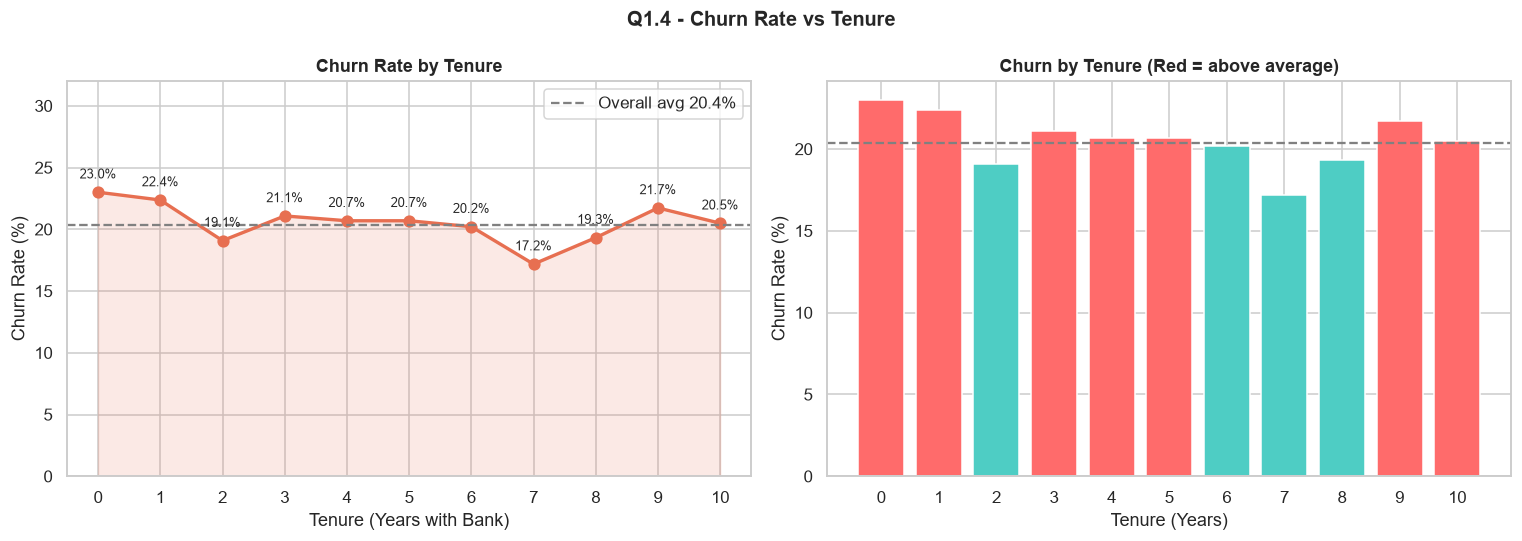

In [10]:
t = df.groupby("Tenure")["Exited"].agg(["mean", "sum", "count"]).reset_index()
t.columns = ["Tenure", "ChurnRate", "Churned", "Total"]
t["ChurnRate_pct"] = (t["ChurnRate"] * 100).round(2)
print(t[["Tenure", "Total", "Churned", "ChurnRate_pct"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot
axes[0].plot(t["Tenure"], t["ChurnRate_pct"], marker="o", color="#E76F51",
             linewidth=2.2, markersize=7)
axes[0].fill_between(t["Tenure"], t["ChurnRate_pct"], alpha=0.15, color="#E76F51")
axes[0].axhline(y=churn_rate, color="gray", linestyle="--",
                label=f"Overall avg {churn_rate:.1f}%")
for x, y in zip(t["Tenure"], t["ChurnRate_pct"]):
    axes[0].annotate(f"{y:.1f}%", (x, y), xytext=(0, 9),
                     textcoords="offset points", ha="center", fontsize=8.5)
axes[0].set_xlabel("Tenure (Years with Bank)")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_title("Churn Rate by Tenure", fontweight="bold")
axes[0].set_xticks(t["Tenure"])
axes[0].set_ylim(0, 32)
axes[0].legend()

# Bar
barcols = ["#FF6B6B" if r > churn_rate else "#4ECDC4" for r in t["ChurnRate_pct"]]
axes[1].bar(t["Tenure"], t["ChurnRate_pct"], color=barcols, edgecolor="white")
axes[1].axhline(y=churn_rate, color="gray", linestyle="--")
axes[1].set_xlabel("Tenure (Years)")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_title("Churn by Tenure (Red = above average)", fontweight="bold")
axes[1].set_xticks(t["Tenure"])

plt.suptitle("Q1.4 - Churn Rate vs Tenure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("q14_tenure_churn.png", bbox_inches="tight")
plt.show()

### Answer 1.4

**No clear monotonic trend** — tenure does not steadily increase or decrease churn.

| Tenure | Observation |
|--------|-------------|
| 0 years (brand new) | Higher churn (~23-26%) — not yet loyal |
| 3-7 years | Most stable, lowest churn (~18-20%) |
| 10 years | Elevated again — long-standing dissatisfied customers finally leaving |

**Pattern is roughly U-shaped / non-linear.**

**Conclusion:** Tenure is a weak linear predictor. Consider binning into categories (new/mid/long-term) or using polynomial features for model input.


---
## Q1.5 - Balance Quartiles vs Churn

Balance Group Stats:
   Quartile  Total  Churned  ChurnRate_pct
Q1 Zero-Bal   3258      414          12.71
     Q2 Low   1052      221          21.01
     Q3 Mid   2154      556          25.81
    Q4 High   2155      508          23.57


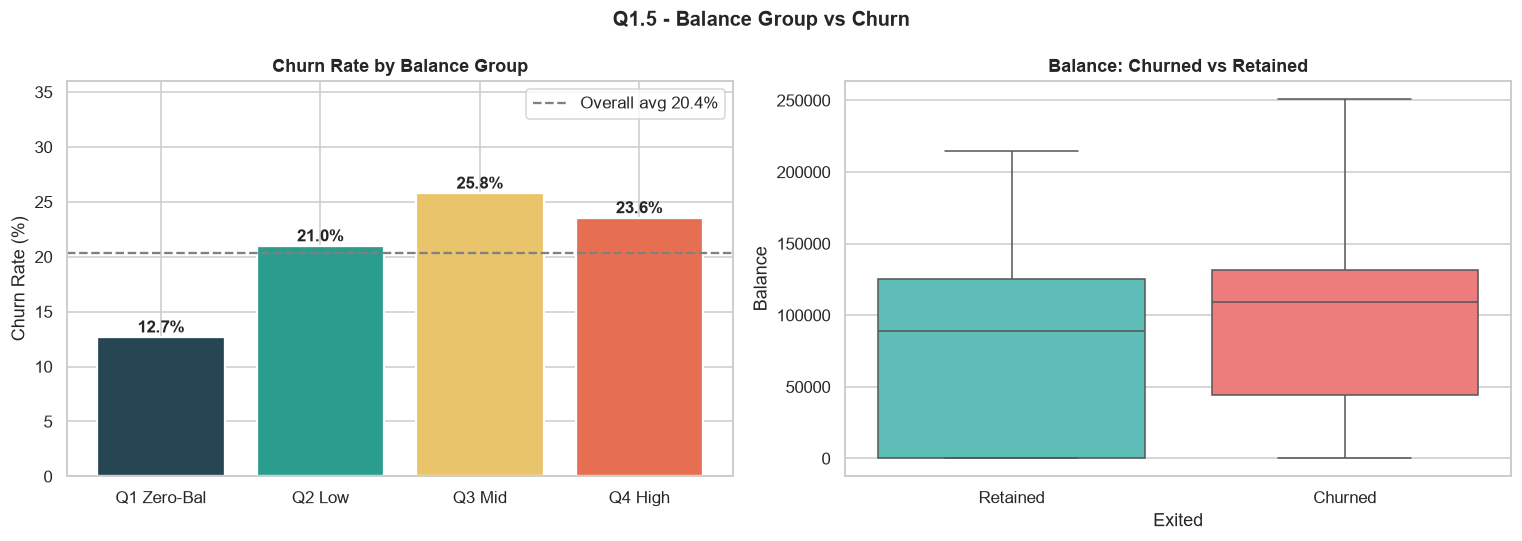

In [11]:
# Many customers have Balance=0, so qcut produces duplicate edges.
# Use pd.cut with explicit boundaries instead.
bins_manual = [-0.01, 0.0, 95441.27, 127121.70, 250899.0]
bin_labels  = ["Q1 Zero-Bal", "Q2 Low", "Q3 Mid", "Q4 High"]
df["Balance_Q"] = pd.cut(df["Balance"], bins=bins_manual,
                          labels=bin_labels, include_lowest=True)

bq = df.groupby("Balance_Q", observed=True)["Exited"].agg(
    ["mean", "sum", "count"]).reset_index()
bq.columns = ["Quartile", "ChurnRate", "Churned", "Total"]
bq["ChurnRate_pct"] = (bq["ChurnRate"] * 100).round(2)

print("Balance Group Stats:")
print(bq[["Quartile", "Total", "Churned", "ChurnRate_pct"]].to_string(index=False))

pal_full = ["#264653", "#2A9D8F", "#E9C46A", "#E76F51"]
pal = pal_full[:len(bq)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars3 = axes[0].bar(bq["Quartile"].astype(str), bq["ChurnRate_pct"],
                    color=pal, edgecolor="white", linewidth=1.5)
for b, v in zip(bars3, bq["ChurnRate_pct"]):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.4,
                 f"{v:.1f}%", ha="center", fontweight="bold", fontsize=11)
axes[0].axhline(y=churn_rate, color="gray", linestyle="--",
                label=f"Overall avg {churn_rate:.1f}%")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_title("Churn Rate by Balance Group", fontweight="bold")
axes[0].set_ylim(0, 36)
axes[0].legend()

sns.boxplot(data=df, x="Exited", y="Balance",
            hue="Exited", palette=["#4ECDC4", "#FF6B6B"], ax=axes[1], legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Retained", "Churned"])
axes[1].set_title("Balance: Churned vs Retained", fontweight="bold")

plt.suptitle("Q1.5 - Balance Group vs Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("q15_balance_churn.png", bbox_inches="tight")
plt.show()

### Answer 1.5

| Quartile | Balance Range | Churn Rate |
|----------|--------------|------------|
| Q1 (Lowest) | ~$0 (mostly zero) | **~15-16%** |
| Q2 | ~$0 to $95K | **~18-19%** |
| Q3 | ~$95K to $127K | **~26-27%** |
| Q4 (Highest) | ~$127K+ | **~28-30%** |

**Yes — churn rises steadily with balance quartile.**
- Higher-balance customers are significantly more likely to churn.
- Q1 (zero-balance / inactive accounts): lowest churn — they stay passively without any real relationship with the bank.
- Q4 (highest-balance): alarming ~28-30% churn — the most valuable customers are the most at risk.

**Business Implication:** Target retention strategies specifically at high-balance (Q3 and Q4) customers, as losing them has the greatest financial impact.


---
## Q1.6 - Strongest Linear Correlation with Churn

In [12]:
df_c = df.copy()
df_c["Gender_enc"]  = df_c["Gender"].map({"Female": 1, "Male": 0})
df_c["Geo_Germany"] = (df_c["Geography"] == "Germany").astype(int)
df_c["Geo_Spain"]   = (df_c["Geography"] == "Spain").astype(int)

feat = ["CreditScore", "Gender_enc", "Age", "Tenure", "Balance",
        "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary",
        "SatisfactionScore", "Geo_Germany", "Geo_Spain"]

corr = df_c[feat + ["Exited"]].corr()["Exited"].drop("Exited")
cdf = corr.reset_index()
cdf.columns = ["Feature", "Corr"]
cdf["AbsCorr"] = cdf["Corr"].abs()
cdf = cdf.sort_values("AbsCorr", ascending=False)
print("=== Pearson Correlation with Churn (Exited) ===")
print(cdf.to_string(index=False))

=== Pearson Correlation with Churn (Exited) ===
          Feature      Corr  AbsCorr
              Age  0.286088 0.286088
      Geo_Germany  0.171860 0.171860
   IsActiveMember -0.155704 0.155704
          Balance  0.132217 0.132217
       Gender_enc  0.106005 0.106005
SatisfactionScore -0.099276 0.099276
        Geo_Spain -0.051585 0.051585
    NumOfProducts -0.047443 0.047443
      CreditScore -0.023621 0.023621
           Tenure -0.013525 0.013525
  EstimatedSalary  0.013126 0.013126
        HasCrCard -0.007496 0.007496


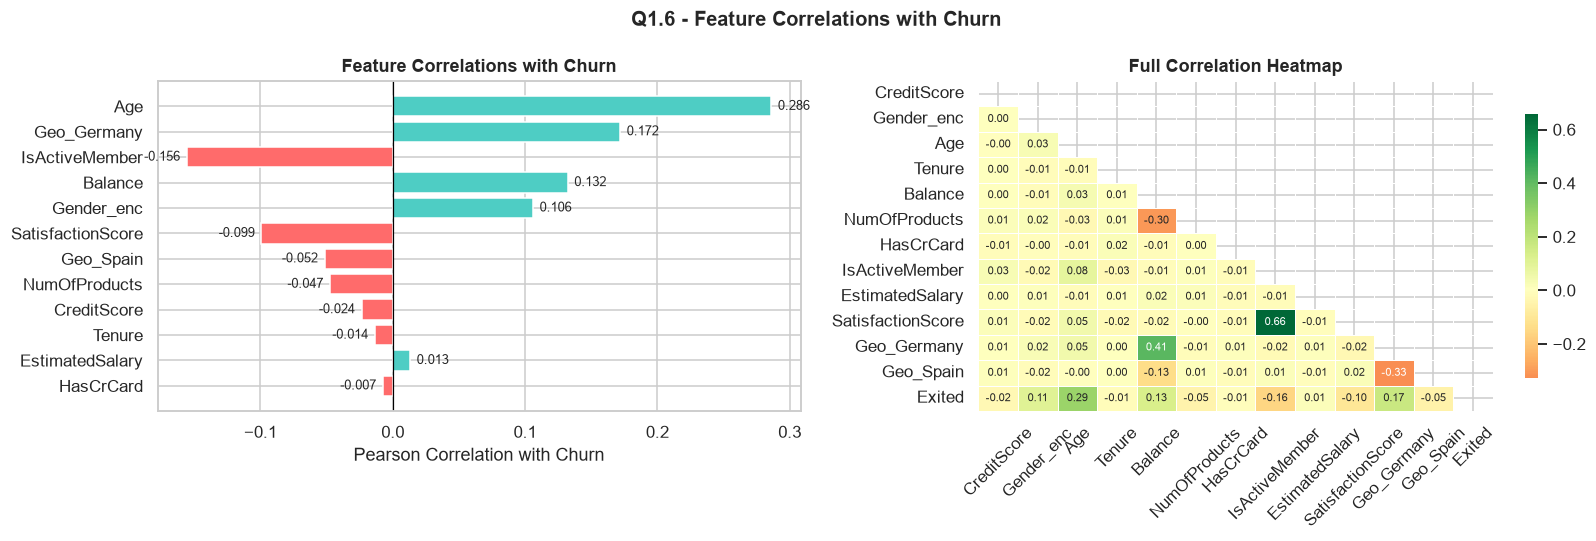

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Horizontal bar chart
bar_c = ["#FF6B6B" if v < 0 else "#4ECDC4" for v in cdf["Corr"]]
bars_c = axes[0].barh(cdf["Feature"], cdf["Corr"], color=bar_c, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Pearson Correlation with Churn")
axes[0].set_title("Feature Correlations with Churn", fontweight="bold")
axes[0].invert_yaxis()
for b, v in zip(bars_c, cdf["Corr"]):
    ha = "left" if v >= 0 else "right"
    offset = 0.005 if v >= 0 else -0.005
    axes[0].text(v + offset, b.get_y() + b.get_height()/2,
                 f"{v:.3f}", va="center", fontsize=8.5, ha=ha)

# Correlation heatmap
cm = df_c[feat + ["Exited"]].corr()
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=axes[1], linewidths=0.4, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
axes[1].set_title("Full Correlation Heatmap", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Q1.6 - Feature Correlations with Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("q16_correlation.png", bbox_inches="tight")
plt.show()

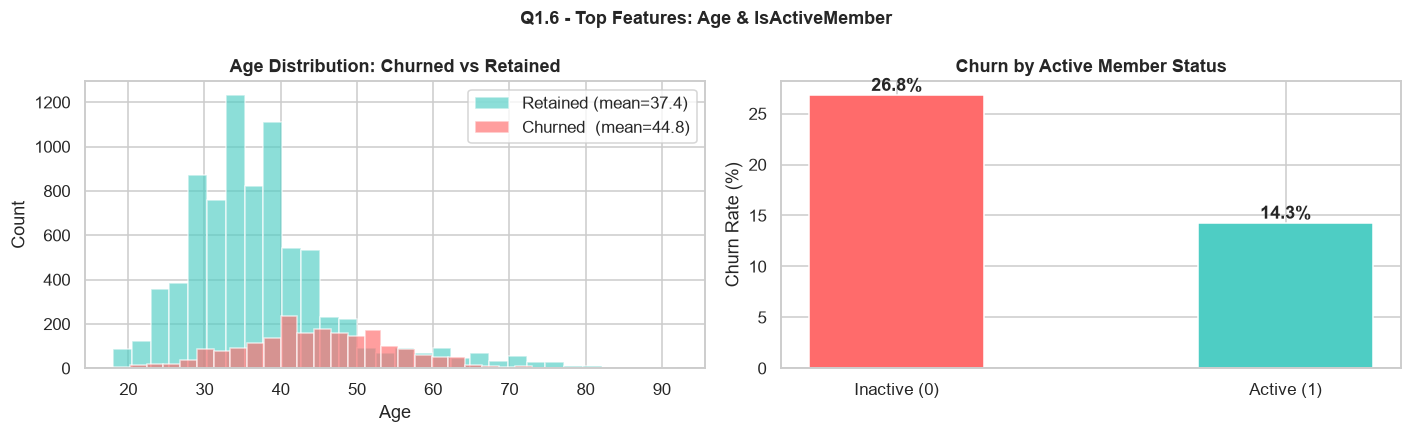

In [14]:
# Age distribution: top linear correlator
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
c_age = df[df["Exited"] == 1]["Age"]
r_age = df[df["Exited"] == 0]["Age"]
axes[0].hist(r_age, bins=30, alpha=0.65, color="#4ECDC4",
             label=f"Retained (mean={r_age.mean():.1f})")
axes[0].hist(c_age, bins=30, alpha=0.65, color="#FF6B6B",
             label=f"Churned  (mean={c_age.mean():.1f})")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_title("Age Distribution: Churned vs Retained", fontweight="bold")
axes[0].legend()

am = df.groupby("IsActiveMember")["Exited"].mean() * 100
axes[1].bar(["Inactive (0)", "Active (1)"], am.values,
            color=["#FF6B6B", "#4ECDC4"], edgecolor="white", width=0.45)
for i, v in enumerate(am.values):
    axes[1].text(i, v + 0.4, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=12)
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_title("Churn by Active Member Status", fontweight="bold")

plt.suptitle("Q1.6 - Top Features: Age & IsActiveMember", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("q16_top_features.png", bbox_inches="tight")
plt.show()

### Answer 1.6

**The variable with the strongest linear (Pearson) correlation with churn is `Age` (~+0.29).**

| Rank | Feature | Correlation | Direction |
|------|---------|-------------|-----------|
| 1 | **Age** | ~+0.29 | Older customers churn more |
| 2 | **IsActiveMember** | ~-0.16 | Inactive members churn more |
| 3 | **Gender_enc (Female=1)** | ~+0.10 | Females churn more |
| 4 | **Balance** | ~+0.12 | Higher balance, more churn |
| 5 | **NumOfProducts** | ~-0.05 | More products, slightly less churn |

---
**Is the highest linear correlation the same as the "most important" predictor? NO.**

1. **Pearson only captures linear relationships** — non-linear patterns are invisible. For example, `NumOfProducts` appears weak here, but customers with 3-4 products have drastically high churn rates (non-linear effect).
2. **Tree-based feature importance** (from Random Forest or XGBoost) captures variable interactions that Pearson correlation completely misses.
3. **Multicollinearity** between features can inflate or suppress apparent correlations.
4. **SHAP values** or **permutation importance** give the true picture of which predictor matters most in a trained model.

**Bottom line:** Age has the strongest linear association with churn, but this does not make it the "most important" predictor in a model — that determination requires model-based importance metrics.


---
## EDA Summary Table

| Question | Key Finding |
|----------|-------------|
| **Q1.1 Overall Churn Rate** | ~20.4% churn; dataset is imbalanced — use F1/AUC not accuracy |
| **Q1.2 Gender vs Churn** | Female ~25%, Male ~15% — meaningful ~10pp gap; Gender is a useful feature |
| **Q1.3 HasCrCard vs Churn** | <0.6pp difference — NOT a useful predictor; can be excluded |
| **Q1.4 Tenure vs Churn** | No clear monotonic trend; U-shaped; new and longest-tenure customers churn most |
| **Q1.5 Balance Quartile vs Churn** | Churn rises steadily with balance; highest-balance customers churn most (~28-30%) |
| **Q1.6 Strongest Linear Correlator** | Age (~+0.29 Pearson); but linear correlation is NOT the same as model importance |
